# 03 — Análise Inferencial

**Atenção**: $n=32$ → poder estatístico baixo. Resultados são **exploratórios**, não confirmatórios.

**Pipeline**:
1. Mann–Whitney U (Wilcoxon Rank Sum) + Cliff's Delta (magnitude por Romano et al., 2006) para 4 pares de subgrupos × 13 características × 2 dimensões (importância e prioridade)
2. Spearman ρ entre n_projects/seniority_ordinal e cada Likert (com IC bootstrap)
3. Holm–Bonferroni para múltiplas comparações
4. Saída: `tables/inferential.tex` consolidando achados significativos

**Subgrupos**:
- Sêniores (Pleno+Sênior, n=20) vs Juniores (Estagiário+Júnior, n=12)
- Cientistas de dados (n=18) vs Desenvolvedores (n=9)
- Mais experientes (>3 projetos) vs Menos experientes (≤3 projetos)
- Homens (n=24) vs Mulheres (n=8) — bonus, mas reportar com cuidado

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

sys.path.insert(0, str(Path.cwd()))
import utils as U

TABLES = U.DATA_PROC / "tables"
df = U.load_anonymized()
print(f"N={len(df)}")

N=32


## 1. Helper: Mann–Whitney + Cliff's Delta

In [2]:
def mwu_delta(g1: pd.Series, g2: pd.Series) -> dict:
    g1 = g1.dropna().astype(float)
    g2 = g2.dropna().astype(float)
    if len(g1) < 2 or len(g2) < 2:
        return {"U": np.nan, "p": np.nan, "delta": np.nan, "magnitude": "insufficient",
                "n1": len(g1), "n2": len(g2), "med1": np.nan, "med2": np.nan}
    U_stat, p = stats.mannwhitneyu(g1, g2, alternative="two-sided")
    delta, mag = U.cliffs_delta(g1, g2)
    return {"U": float(U_stat), "p": float(p), "delta": delta, "magnitude": mag,
            "n1": int(len(g1)), "n2": int(len(g2)),
            "med1": float(g1.median()), "med2": float(g2.median())}

## 2. Comparações entre subgrupos

Para cada par de subgrupos × cada Likert (importância e prioridade).

In [3]:
comparisons = [
    ("Sêniores × Juniores",
     df[df["seniority_group"] == "senior"], df[df["seniority_group"] == "junior"]),
    ("Cient. dados × Desenvolvedores",
     df[df["role_group"] == "data_scientist"], df[df["role_group"] == "developer"]),
    (">3 projetos × ≤3 projetos",
     df[df["n_projects"] > 3], df[df["n_projects"] <= 3]),
    ("Homens × Mulheres",
     df[df["gender"] == "Homem"], df[df["gender"] == "Mulher"]),
]

def collect_tests(comparisons, cols, dim_label):
    rows = []
    for comp_name, g1, g2 in comparisons:
        for col in cols:
            char = col.split("_", 1)[1]
            r = mwu_delta(g1[col], g2[col])
            rows.append({"dim": dim_label, "comparison": comp_name,
                         "characteristic": char, **r})
    return pd.DataFrame(rows)

imp_tests = collect_tests(comparisons, U.IMP_COLS, "importância")
pri_tests = collect_tests(comparisons, U.PRI_COLS, "prioridade")
tests = pd.concat([imp_tests, pri_tests], ignore_index=True)
print(f"Testes totais: {len(tests)}")
tests.head()

Testes totais: 104


,dim,comparison,characteristic,U,p,delta,magnitude,n1,n2,med1,med2
0,importância,Sêniores × Juniores,precision,105.5,0.387534,-0.120833,negligible,20,12,5.0,5.0
1,importância,Sêniores × Juniores,completeness,147.0,0.233791,0.225000,small,20,12,5.0,4.0
2,importância,Sêniores × Juniores,consistency,118.5,0.958816,-0.012500,negligible,20,12,5.0,5.0
3,importância,Sêniores × Juniores,credibility,143.5,0.253089,0.195833,small,20,12,5.0,5.0
4,importância,Sêniores × Juniores,currentness,115.0,0.851398,-0.041667,negligible,20,12,4.0,4.0


## 3. Correção Holm–Bonferroni

Aplicada **dentro de cada par comparativo × dimensão** (evita inflar correção sobre comparações desconectadas).

In [4]:
def add_holm(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["p_holm"] = np.nan
    out["sig_raw"] = out["p"] < 0.05
    out["sig_holm"] = False
    for (comp, dim), grp in out.groupby(["comparison", "dim"]):
        valid = grp["p"].notna()
        if valid.sum() == 0:
            continue
        reject, p_adj, _, _ = multipletests(grp.loc[valid, "p"], method="holm")
        idx = grp.loc[valid].index
        out.loc[idx, "p_holm"] = p_adj
        out.loc[idx, "sig_holm"] = reject
    return out

tests = add_holm(tests)
sig_raw = tests[tests["sig_raw"]]
sig_holm = tests[tests["sig_holm"]]
print(f"Significativos (p<0.05 bruto): {len(sig_raw)}")
print(f"Significativos pós-Holm: {len(sig_holm)}")
print("\nMaiores efeitos (|delta| ≥ 0.33, p bruto < 0.05):")
interesting = tests[(tests["sig_raw"]) & (tests["delta"].abs() >= 0.33)].sort_values("delta", key=abs, ascending=False)
print(interesting[["dim", "comparison", "characteristic", "med1", "med2", "delta", "magnitude", "p", "p_holm"]].to_string(index=False))

Significativos (p<0.05 bruto): 16
Significativos pós-Holm: 2

Maiores efeitos (|delta| ≥ 0.33, p bruto < 0.05):
        dim                     comparison    characteristic  med1  med2     delta magnitude        p   p_holm
 prioridade      >3 projetos × ≤3 projetos        efficiency   3.0   4.5 -0.703125     large 0.000471 0.006121
 prioridade Cient. dados × Desenvolvedores       currentness   4.0   3.0  0.627778     large 0.005412 0.070355
 prioridade            Sêniores × Juniores        efficiency   3.0   5.0 -0.604167     large 0.003669 0.047694
importância              Homens × Mulheres      availability   4.0   5.0 -0.583333     large 0.006914 0.089877
importância            Sêniores × Juniores        efficiency   4.0   5.0 -0.550000     large 0.005517 0.071722
importância      >3 projetos × ≤3 projetos        efficiency   4.0   5.0 -0.546875     large 0.004356 0.056629
 prioridade      >3 projetos × ≤3 projetos      availability   3.0   4.5 -0.500000     large 0.012140 0.133545


## 4. Spearman ρ — projetos × Likerts; senioridade × Likerts

Correlação ρ por característica entre `n_projects`/`seniority_ordinal` e cada Likert (Q11/Q13).

- **IC 95% bootstrap pareado** (BCa, 10k resamples; fallback para percentile se BCa degenerar).
- Reportamos ρ [IC95%] em vez de só p-valor — mais informativo dado N=32.


In [5]:
def spearman_rows(predictor: str, cols: list[str], dim: str,
                  n_boot: int = 10_000) -> pd.DataFrame:
    rows = []
    for col in cols:
        res = U.spearman_with_ci(df[predictor], df[col], n_resamples=n_boot)
        if res["method"] == "insufficient":
            continue
        rows.append({"dim": dim, "predictor": predictor,
                     "characteristic": col.split("_", 1)[1],
                     **res})
    return pd.DataFrame(rows)

spear = pd.concat([
    spearman_rows("n_projects", U.IMP_COLS, "importância"),
    spearman_rows("n_projects", U.PRI_COLS, "prioridade"),
    spearman_rows("seniority_ordinal", U.IMP_COLS, "importância"),
    spearman_rows("seniority_ordinal", U.PRI_COLS, "prioridade"),
], ignore_index=True)
spear["sig_raw"] = spear["p"] < 0.05
spear["ci_excludes_zero"] = (spear["ci_lo"] > 0) | (spear["ci_hi"] < 0)

print(f"Spearman: {len(spear)} testes")
print(f"Significativos (bruto p<0.05): {spear['sig_raw'].sum()}")
print(f"IC 95% exclui zero:            {spear['ci_excludes_zero'].sum()}")
print(f"Métodos de IC: {spear['method'].value_counts().to_dict()}")
print()
disp_cols = ["dim", "predictor", "characteristic", "n", "rho", "ci_lo", "ci_hi", "p", "method"]
print("Top correlações |ρ|:")
print(spear.sort_values("rho", key=abs, ascending=False).head(10)[disp_cols].to_string(index=False))
print()
print("Significativos (bruto):")
if spear["sig_raw"].any():
    print(spear[spear["sig_raw"]].sort_values("p")[disp_cols].to_string(index=False))
else:
    print("  (nenhum)")


Spearman: 52 testes
Significativos (bruto p<0.05): 10
IC 95% exclui zero:            9
Métodos de IC: {'bca': 52}

Top correlações |ρ|:
        dim         predictor characteristic  n       rho     ci_lo     ci_hi        p method
 prioridade        n_projects     efficiency 32 -0.628441 -0.810064 -0.338370 0.000117    bca
 prioridade seniority_ordinal     efficiency 32 -0.551198 -0.744844 -0.267452 0.001077    bca
importância seniority_ordinal     efficiency 32 -0.445681 -0.679236 -0.089944 0.010576    bca
 prioridade        n_projects    reliability 32 -0.414965 -0.667420 -0.070413 0.018196    bca
 prioridade seniority_ordinal   availability 32 -0.404513 -0.643385 -0.076164 0.021655    bca
 prioridade        n_projects   availability 32 -0.396168 -0.656303 -0.021037 0.024791    bca
importância seniority_ordinal recoverability 32 -0.378977 -0.641979 -0.030734 0.032433    bca
 prioridade seniority_ordinal recoverability 32 -0.373360 -0.638036 -0.017158 0.035308    bca
importância       

## 5. Heatmap subgrupos × características — % alta + diferença vs Total

Já temos o heatmap simples no notebook 02. Aqui derivamos uma figura com diferenças (subgrupo − total) para destacar onde os subgrupos divergem.

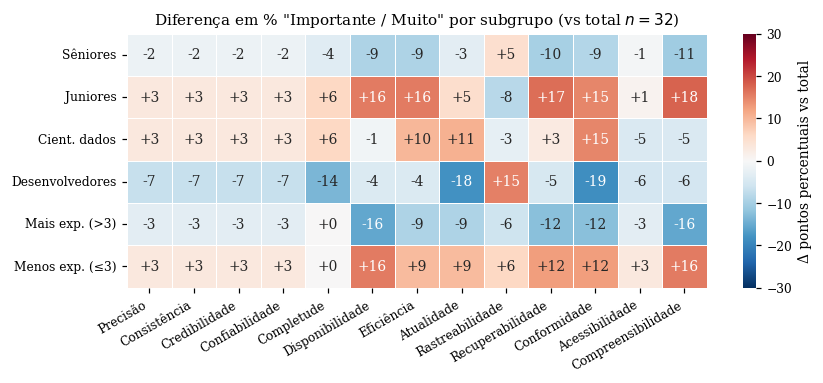

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
U.setup_matplotlib()

def pct_top2(g, col):
    s = g[col].dropna()
    return (s >= 4).sum() / len(s) * 100 if len(s) else np.nan

groups_def = {
    "Sêniores": df[df["seniority_group"] == "senior"],
    "Juniores": df[df["seniority_group"] == "junior"],
    "Cient. dados": df[df["role_group"] == "data_scientist"],
    "Desenvolvedores": df[df["role_group"] == "developer"],
    "Mais exp. (>3)": df[df["n_projects"] > 3],
    "Menos exp. (≤3)": df[df["n_projects"] <= 3],
}
total_imp = pd.Series({c: pct_top2(df, f"imp_{c}") for c in U.CHARACTERISTICS_PT.keys()})
diffs = pd.DataFrame({
    label: [pct_top2(g, f"imp_{c}") - total_imp[c] for c in U.CHARACTERISTICS_PT.keys()]
    for label, g in groups_def.items()
}, index=[U.CHARACTERISTICS_PT[c] for c in U.CHARACTERISTICS_PT.keys()]).T
diffs = diffs[total_imp.sort_values(ascending=False).rename(lambda c: U.CHARACTERISTICS_PT[c]).index]

fig, ax = plt.subplots(figsize=(8.5, 3.0))
sns.heatmap(diffs, annot=True, fmt="+.0f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Δ pontos percentuais vs total"},
            linewidths=0.4, linecolor="white", ax=ax, vmin=-30, vmax=30)
ax.set_title("Diferença em % \"Importante / Muito\" por subgrupo (vs total $n=32$)")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
U.save_fig(fig, "heatmap_subgroup_diff")
plt.show()

## 6. Tabela 3 — testes inferenciais

Inclui **só** comparações com p<0.05 ou |delta|>=0.33 + magnitude small/medium/large. Mantém honestidade: reportar tudo no replication package, citar só o relevante no paper.

In [7]:
tests.to_csv(TABLES / "inferential_full.csv", index=False)
spear.to_csv(TABLES / "spearman_full.csv", index=False)
print(f"[saved] tables/inferential_full.csv ({len(tests)} linhas)")
print(f"[saved] tables/spearman_full.csv ({len(spear)} linhas)")

# Tabela LaTeX só com achados não-negligenciáveis (|delta|>=0.33 OU sig)
report = tests[(tests["sig_raw"]) | (tests["delta"].abs() >= 0.33)].copy()
report = report.sort_values(["comparison", "dim", "p"]).reset_index(drop=True)

def format_p(p):
    if pd.isna(p):
        return "--"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"

lines = [
    "\\begin{table*}[t]",
    "\\caption{Comparações exploratórias entre subgrupos. Mann–Whitney $U$, Cliff's $\\delta$ (Romano et al., 2006), $p_{\\text{Holm}}$ corrigido por par comparativo. Exibidas apenas linhas com $p<0.05$ ou $|\\delta|\\geq 0.33$.}",
    "\\label{tab:inferential}",
    "\\centering",
    "\\small",
    "\\begin{tabular}{llllrrrll}",
    "\\toprule",
    "\\textbf{Comparação} & \\textbf{Dim.} & \\textbf{Característica} & \\textbf{Med.} & $\\delta$ & \\textbf{Mag.} & $U$ & $p$ & $p_{\\text{Holm}}$ \\\\",
    "\\midrule",
]
for _, r in report.iterrows():
    char = U.CHARACTERISTICS_PT.get(r["characteristic"], r["characteristic"])
    med_str = f"{r['med1']:.0f} vs {r['med2']:.0f}"
    lines.append(
        f"{r['comparison']} & {r['dim']} & {char} & {med_str} & {r['delta']:+.2f} & {r['magnitude']} & {r['U']:.0f} & {format_p(r['p'])} & {format_p(r['p_holm'])} \\\\"
    )
lines.extend(["\\bottomrule", "\\end{tabular}", "\\end{table*}"])
(TABLES / "inferential.tex").write_text("\n".join(lines))
print(f"[saved] tables/inferential.tex ({len(report)} linhas no paper)")
report[["comparison", "dim", "characteristic", "med1", "med2", "delta", "magnitude", "p", "p_holm"]]

[saved] tables/inferential_full.csv (104 linhas)
[saved] tables/spearman_full.csv (52 linhas)
[saved] tables/inferential.tex (36 linhas no paper)


,comparison,dim,characteristic,med1,med2,delta,magnitude,p,p_holm
0,>3 projetos × ≤3 projetos,importância,efficiency,4.0,5.0,-0.546875,large,0.004356,0.056629
1,>3 projetos × ≤3 projetos,importância,recoverability,4.0,5.0,-0.359375,medium,0.059783,0.717401
2,>3 projetos × ≤3 projetos,importância,availability,4.0,5.0,-0.347656,medium,0.063677,0.717401
3,>3 projetos × ≤3 projetos,prioridade,efficiency,3.0,4.5,-0.703125,large,0.000471,0.006121
4,>3 projetos × ≤3 projetos,prioridade,reliability,4.0,5.0,-0.472656,medium,0.009518,0.114220
5,>3 projetos × ≤3 projetos,prioridade,availability,3.0,4.5,-0.500000,large,0.012140,0.133545
6,>3 projetos × ≤3 projetos,prioridade,recoverability,3.0,4.0,-0.488281,large,0.014158,0.141576
7,>3 projetos × ≤3 projetos,prioridade,compliance,3.0,5.0,-0.402344,medium,0.038362,0.345261
8,>3 projetos × ≤3 projetos,prioridade,understandability,3.0,4.0,-0.402344,medium,0.043550,0.348401
9,>3 projetos × ≤3 projetos,prioridade,accessibility,3.0,4.0,-0.332031,medium,0.096572,0.676005


## 7. Sumário inferencial — texto plug-and-play pro paper

In [8]:
# Achados textuais resumidos
report_text = []
if len(sig_holm):
    for _, r in sig_holm.iterrows():
        char = U.CHARACTERISTICS_PT.get(r["characteristic"], r["characteristic"])
        report_text.append(
            f"[{r['comparison']}, {r['dim']}] {char}: "
            f"$\\delta$={r['delta']:+.2f} ({r['magnitude']}), p={r['p']:.3f}, p_Holm={r['p_holm']:.3f}."
        )
else:
    report_text.append("Nenhuma comparação sobreviveu correção Holm. Reportar como exploratório.")

for _, r in interesting.iterrows():
    if not r['sig_holm']:
        char = U.CHARACTERISTICS_PT.get(r["characteristic"], r["characteristic"])
        report_text.append(
            f"[{r['comparison']}, {r['dim']}] {char}: "
            f"$\\delta$={r['delta']:+.2f} ({r['magnitude']}), p={r['p']:.3f} bruto (não sobreviveu Holm) — reportar como tendência."
        )

for line in report_text:
    print(line)

(TABLES / "inferential_findings.txt").write_text("\n".join(report_text))
print("\n[saved] tables/inferential_findings.txt")

[Sêniores × Juniores, prioridade] Eficiência: $\delta$=-0.60 (large), p=0.004, p_Holm=0.048.
[>3 projetos × ≤3 projetos, prioridade] Eficiência: $\delta$=-0.70 (large), p=0.000, p_Holm=0.006.
[Cient. dados × Desenvolvedores, prioridade] Atualidade: $\delta$=+0.63 (large), p=0.005 bruto (não sobreviveu Holm) — reportar como tendência.
[Homens × Mulheres, importância] Disponibilidade: $\delta$=-0.58 (large), p=0.007 bruto (não sobreviveu Holm) — reportar como tendência.
[Sêniores × Juniores, importância] Eficiência: $\delta$=-0.55 (large), p=0.006 bruto (não sobreviveu Holm) — reportar como tendência.
[>3 projetos × ≤3 projetos, importância] Eficiência: $\delta$=-0.55 (large), p=0.004 bruto (não sobreviveu Holm) — reportar como tendência.
[>3 projetos × ≤3 projetos, prioridade] Disponibilidade: $\delta$=-0.50 (large), p=0.012 bruto (não sobreviveu Holm) — reportar como tendência.
[Homens × Mulheres, prioridade] Disponibilidade: $\delta$=-0.49 (large), p=0.034 bruto (não sobreviveu Holm) 

## 8. Wilcoxon pareado — Importância × Prioridade

Within-subject: para cada característica, testa se o respondente atribui escores diferentes em Q11 (importância) e Q13 (prioridade). Formaliza o gap descritivo da Seção 6 do notebook 02.

- Effect size: matched-pairs rank-biserial *r* (Kerby 2014); |r| < 0.1 negligible, < 0.3 small, < 0.5 medium, ≥ 0.5 large.
- Holm–Bonferroni dentro da família das 13 características.
-  ⇒ importância tipicamente acima de prioridade (i.e., há gap).


In [9]:
rows = []
for col_imp, col_pri in zip(U.IMP_COLS, U.PRI_COLS):
    char = col_imp.split("_", 1)[1]
    res = U.wilcoxon_paired(df[col_imp], df[col_pri])
    rows.append({"characteristic": char,
                 "med_imp": float(df[col_imp].median()),
                 "med_pri": float(df[col_pri].median()),
                 **res})
paired = pd.DataFrame(rows)

valid = paired["p"].notna()
if valid.sum():
    reject, p_adj, _, _ = multipletests(paired.loc[valid, "p"], method="holm")
    paired["p_holm"] = float("nan")
    paired.loc[valid, "p_holm"] = p_adj
    paired["sig_holm"] = False
    paired.loc[valid, "sig_holm"] = reject
else:
    paired["p_holm"] = float("nan")
    paired["sig_holm"] = False
paired["sig_raw"] = paired["p"] < 0.05

paired_disp = paired[["characteristic", "n", "med_imp", "med_pri", "med_diff",
                      "r_rb", "magnitude", "W", "p", "p_holm", "sig_holm"]]
print(f"Pareados significativos (bruto p<0.05): {paired['sig_raw'].sum()}")
print(f"Pareados significativos pós-Holm:       {paired['sig_holm'].sum()}")
print()
print(paired_disp.sort_values("r_rb", key=abs, ascending=False).to_string(index=False))


Pareados significativos (bruto p<0.05): 5
Pareados significativos pós-Holm:       1

   characteristic  n  med_imp  med_pri  med_diff     r_rb magnitude    W        p   p_holm  sig_holm
     availability 32      5.0      4.0       0.0 0.879121     large  5.5 0.003159 0.041064      True
   recoverability 32      5.0      4.0       0.0 0.783333     large 13.0 0.004502 0.054023     False
       efficiency 32      4.0      4.0       0.0 0.649123     large 30.0 0.011238 0.112384     False
      currentness 32      4.0      3.5       0.5 0.610390     large 45.0 0.008813 0.096948     False
        precision 32      5.0      5.0       0.0 0.600000     large  9.0 0.083265 0.589106     False
     completeness 32      5.0      4.0       0.0 0.600000     large 21.0 0.029049 0.261441     False
      consistency 32      5.0      5.0       0.0 0.555556     large  8.0 0.131668 0.790008     False
       compliance 32      4.0      4.5       0.0 0.523810     large  5.0 0.234194 0.948917     False
      

In [10]:
# Salva tabela auxiliar pra inspeção/uso futuro no paper
out_path = U.DATA_PROC / "tables" / "wilcoxon_imp_vs_pri.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
paired_disp.to_csv(out_path, index=False)
print(f"-> {out_path.relative_to(U.ROOT)}")


-> data/processed/tables/wilcoxon_imp_vs_pri.csv
